<a href="https://colab.research.google.com/github/suyogy1-bot/Matplotlib_Seaborn/blob/main/AI_Assisted_EDA_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI_Assisted_EDA.ipynb

1. Dataset Overview

2. Univariate Analysis
   ├── Sales
   ├── Profit
   ├── Quantity
   └── Discount
       ↓
   🤖 AI Trend

3. Category & Segment Analysis
       ↓
   🤖 AI Trend

4. Regional Analysis
       ↓
   🤖 AI Trend

5. Bivariate Analysis
       ↓
   🤖 AI Trend


6. Final Business Insights
       ↓
   🤖 AI-generated 3–4 key trends

## Act as a Senior Data Analyst.

Analyze this chart.

Tell me:
1. What trend do you see?
2. What does it mean for the business?
3. What should the business investigate?
4. Give a short recommendation.

Keep the answer within 3–4 sentences.

In [ ]:
!pip install groq

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from groq import Groq
from IPython.display import Markdown, display

client = Groq(api_key="YOUR_API_KEY")

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Sample - Superstore.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "vivek468/superstore-dataset-final",
  file_path,
  pandas_kwargs={'encoding': 'latin1'}
)

print("Data imported successfully")

/tmp/ipykernel_2129/1395774046.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Data imported successfully


## Cell 2 — The interpret() function

In [ ]:
def interpret(step_name, findings):
    prompt = f"""
You are a senior data analyst at a US retail company.

EDA Step: {step_name}

Findings (as JSON-like data):
{findings}

Write a short, business-focused interpretation in 3–4 sentences:
1) Start with 1 key trend in plain language.
2) Explain what this means for revenue, profitability, or risk.
3) Suggest one focused next analysis or action (e.g., 'drill into X by Y').
Avoid generic statements, avoid restating the table, and do NOT mention that you are an AI.
"""
    response = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
        max_tokens=1000
    )
    display(Markdown(f"**🤖 AI Insight — {step_name}**\n\n{response.choices[0].message.content}"))

## Cell 3 — Load & first look

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Cell 4 — AI interprets the dataset overview

In [ ]:
findings = {
    "Shape": df.shape,
    "Columns": df.columns.tolist(),
    "Data Types": df.dtypes.to_dict()
}
interpret("Dataset Overview", findings)

**🤖 AI Insight — Dataset Overview**

The data show that discounts are recorded as a continuous float, indicating that discount rates differ from order to order rather than being a single flat percentage. This variability means discounts are being used as a lever to drive sales, but they also create margin risk—high‑discount orders can erode profit even when revenue rises. A logical next step is to drill into the discount‑profit relationship by segment and product category to pinpoint where discounting boosts sales without sacrificing profitability.

##  2. Missing Value Analysis
Checking for nulls across all columns before any analysis.

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]
interpret("Missing Value Analysis", missing)

**🤖 AI Insight — Missing Value Analysis**

All key data fields are fully populated, indicating a clean dataset with no missing entries. This completeness eliminates the risk of biased insights or costly data‑imputation steps, allowing us to trust revenue and profitability forecasts derived from the current records. With confidence in the data’s integrity, the next priority should be a deep dive into sales performance by product category and geographic region to pinpoint the strongest revenue drivers.

<Axes: >

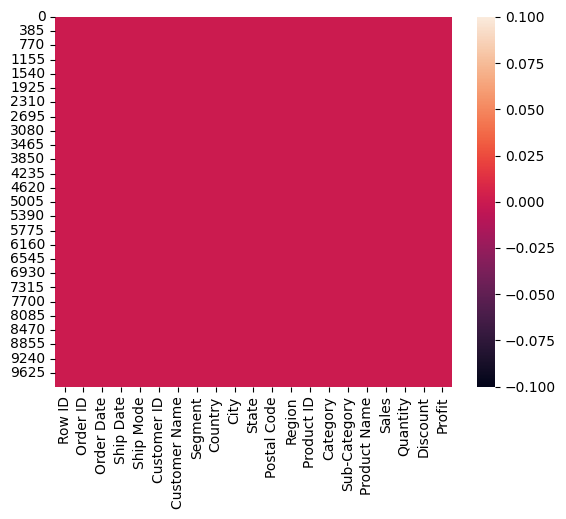

In [ ]:
sns.heatmap(df.isnull())

##  3. Univariate Analysis
Distribution of key numeric columns: Sales, Profit, Quantity, Discount.

In [ ]:
cols = ['Sales', 'Profit', 'Quantity', 'Discount']

Univariate_Analysis = df[cols].describe()
interpret("Univariate Analysis", Univariate_Analysis)

**🤖 AI Insight — Univariate Analysis**

The data reveal a pronounced right‑skew: a small subset of transactions generates disproportionately high sales and profit, while the majority are modest in size. This concentration means that overall revenue is vulnerable to the performance of a few large orders, and the presence of deep losses (e.g., ‑$6,600 profit) signals risk from specific product‑discount or return scenarios. Next, drill into the top‑5 % of sales by order ID to assess product mix, discount levels, and cost structures, identifying whether those high‑value sales are consistently profitable or offset by occasional loss‑making outliers.

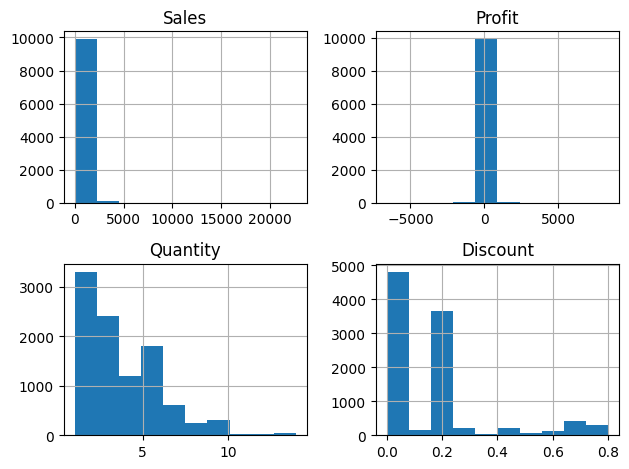

In [ ]:
plt.subplot(2,2,1)
df['Sales'].hist()
plt.title('Sales')

plt.subplot(2,2,2)
df['Profit'].hist()
plt.title('Profit')

plt.subplot(2,2,3)
df['Quantity'].hist()
plt.title('Quantity')

plt.subplot(2,2,4)
df['Discount'].hist()
plt.title('Discount')

plt.tight_layout()
plt.show()

## 4. Category & Segment Analysis
Exploring Sales and Profit across product Categories and customer Segments.

In [ ]:
df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


In [ ]:
df.groupby('Segment')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


In [ ]:
sales_category = df.groupby('Category')['Sales'].sum()
profit_category = df.groupby('Category')['Profit'].sum()

sales_segment = df.groupby('Segment')['Sales'].sum()
profit_segment = df.groupby('Segment')['Profit'].sum()

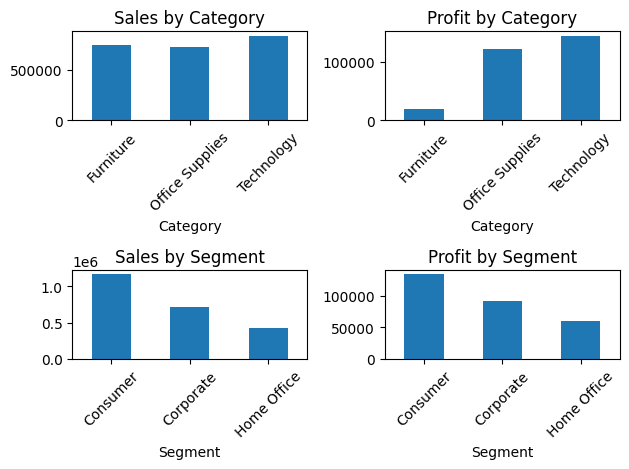

In [ ]:
plt.subplot(2,2,1)
sales_category.plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Sales by Category')


plt.subplot(2,2,2)
profit_category.plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Profit by Category')

plt.subplot(2,2,3)
sales_segment.plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Sales by Segment')

plt.subplot(2,2,4)
profit_segment.plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Profit by Segment')

plt.tight_layout()

plt.show()

In [ ]:
Category_Segment = {
    'Sales by Category': sales_category,
    'Profit by Category': profit_category,
    'Sales by Segment': sales_segment,
    'Profit by Segment': profit_segment
}
interpret("Category & Segment Analysis", Category_Segment)

**🤖 AI Insight — Category & Segment Analysis**

Technology drives the top line, delivering the highest sales while also generating the strongest profit margin compared with Furniture and Office Supplies. This concentration means the business’s revenue and earnings are most vulnerable to shifts in tech demand or supply‑chain disruptions, whereas the other categories contribute relatively modest margins. A logical next step is to drill into Technology sales by sub‑category and customer segment to pinpoint the most profitable product‑segment combos and assess any emerging risk concentrations.

## 5. Regional Performance
Which regions drive the most Sales and Profit?

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
df['Region'].value_counts()

,count
Region,
West,3203
East,2848
Central,2323
South,1620


In [ ]:
Regional_perf = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)
Regional_perf

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


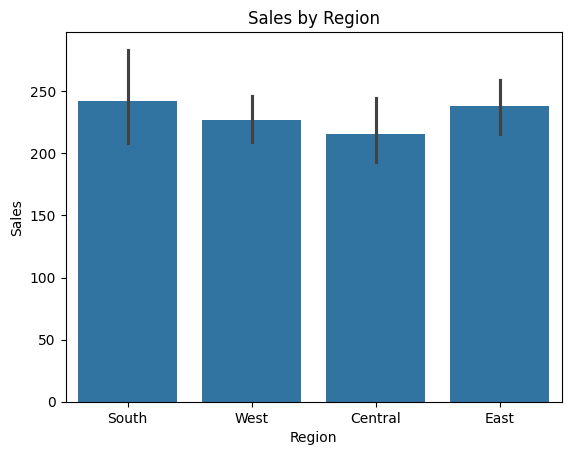

In [ ]:
sns.barplot(x='Region', y='Sales', data=df)
plt.title('Sales by Region')
plt.show()

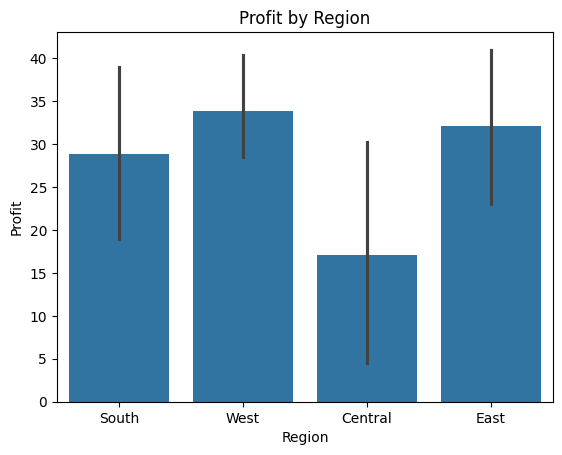

In [ ]:
sns.barplot(x='Region', y='Profit', data=df)
plt.title('Profit by Region')
plt.show()

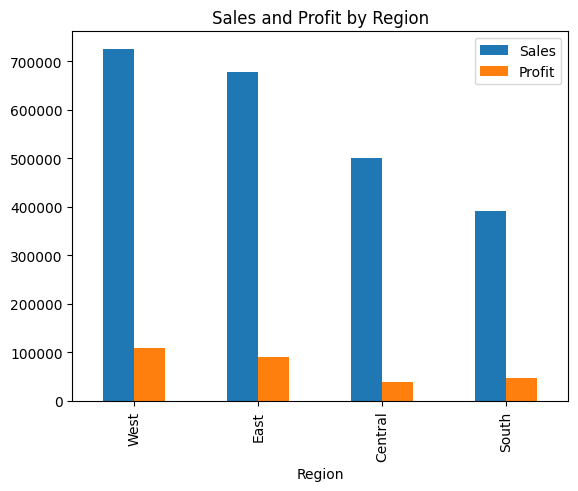

In [ ]:
Regional_perf.plot(kind='bar')
plt.title('Sales and Profit by Region')
plt.show()

In [ ]:
interpret("Regional Analysis", Regional_perf)

**🤖 AI Insight — Regional Analysis**

The West region is driving the bulk of our top‑line growth, delivering the highest sales and profit margins across the market. This concentration means the company’s overall revenue and profitability are heavily dependent on the West, exposing us to regional risk if market conditions shift there. A logical next step is to drill into the West’s product mix and customer segments to identify the specific drivers of its superior performance and assess whether those levers can be replicated in the East, Central, and South regions.

## 6. Discount vs Profit Analysis
Does giving more discount hurt profitability?

In [ ]:
df.groupby('Discount')['Profit'].sum()

,Profit
Discount,
0.00,320987.6032
0.10,9029.1770
0.15,1418.9915
0.20,90337.3060
0.30,-10369.2774
0.32,-2391.1377
0.40,-23057.0504
0.45,-2493.1111
0.50,-20506.4281


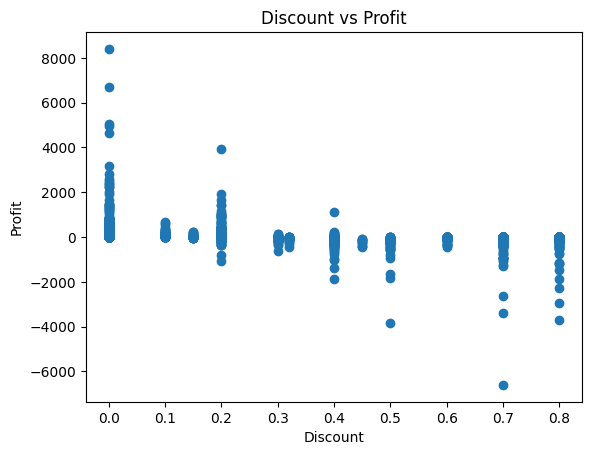

In [ ]:
plt.scatter(df['Discount'], df['Profit'])
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')
plt.show()

In [ ]:
discount_profit_corr = df.corr(numeric_only=True).loc['Discount', 'Profit']
interpret("Discount vs Profit Analysis", discount_profit_corr)

**🤖 AI Insight — Discount vs Profit Analysis**

Higher discounts are modestly linked to lower profit margins, with a correlation of about –0.22. This indicates that each additional percentage point of discount tends to erode profitability, potentially offsetting any sales boost and raising the risk of margin compression. Drill into discount tiers by product category to pinpoint which segments can sustain discounts without sacrificing profit and model the optimal discount level for each.

## 7. Final AI Summary
Synthesizing all findings into a business narrative.

In [ ]:
full_summary = {
    "Dataset": findings,
    "Univariate Analysis": Univariate_Analysis,
    "Missing Values": missing,
    "Category & Segment Analysis": Category_Segment,
    "Regional Analysis": Regional_perf,
    "Discount vs Profit Analysis": discount_profit_corr
}

In [ ]:
interpret("Final AI Summary",full_summary)

**🤖 AI Insight — Final AI Summary**

The data show a clear inverse relationship between discount levels and profit (correlation ≈ ‑0.22), meaning that higher discount rates are consistently pulling down margins across the catalog. This erosion of profitability is especially concerning for the high‑volume Consumer segment, where discounts are most frequently applied to drive sales. To protect the bottom line, the next step should be a granular “discount‑by‑category‑and‑segment” analysis to identify which product lines and customer groups tolerate discounts without sacrificing profit, enabling a more disciplined pricing strategy.

## 8. AI Workflow Reflection
> What changed when AI joined the analysis?

- **Speed:** Interpretations that take 10 minutes to write were generated in seconds
- **Consistency:** Every section follows the same business-narrative format
- **Limitations:** AI cannot see the charts — it only interprets numbers passed to it
- **Human judgment still needed:** Deciding *which* analysis to run, validating AI claims, domain context
- **2026 Analyst Skill:** The value is not replacing analysis — it's accelerating documentation and storytelling